# Exploratory Data Analysis
## image structure

In [82]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import cv2 as cv
import re

### Data loading

In [3]:
data_path = Path.cwd().parent.joinpath('data/vial')
if not data_path.exists():
    raise FileExistsError("could not find the vial folder... Please check")

all_files = []
count_images = 0
#capture le dossier de split, eventuellement la catégorie si existante (bad, good etc.) le filename (ie l'id de l'image), le defect existant et l'extension de l'image
regex = r'/vial/(?P<split>[^/]+)(?:/(?P<category>([^/]+)))?/(?P<filename>[\d]+)\_(?P<defect>[^.]+)\.(?P<extension>[^$]+)'
regex_mask = r'/vial/(?P<split>[^/]+)(?:/(?P<type>([^/]+)))?/(?P<category>[^/]+)/(?P<filename>[\d]+)\_(?P<defect>[^.]+)_mask\.(?P<extension>[^$]+)'
for sub in data_path.iterdir():
    for imgs in sub.rglob("*.png"):
        count_images+=1
        match = re.search(regex, str(imgs))
        match_mask = re.search(regex_mask, str(imgs))
        if match is not None:
            all_files.append({
                'data_type' : 'image',
                'split' : match.group('split'),
                'category' : match.group('category'),
                'filename' : match.group('filename'),
                'defect' : match.group('defect'),
                'extension' : match.group('extension'),
                'path' : imgs
            })
        elif match_mask is not None:
            all_files.append({
                'data_type' : 'mask',
                'split' : match_mask.group('split'),
                'type' : match_mask.group('type'),
                'category' : match_mask.group('category'),
                'filename' : match_mask.group('filename'),
                'defect' : match_mask.group('defect'),
                'extension' : match_mask.group('extension'),
                'path' : imgs
            })
        else:
            print('imgs')
df = pd.DataFrame(all_files)

In [4]:
df["data_type"].value_counts(dropna=False)

data_type
image    1024
mask      105
Name: count, dtype: int64

In [5]:
df["split"].value_counts(dropna=False)

split
train                 291
test_private_mixed    276
test_private          276
test_public           245
validation             41
Name: count, dtype: int64

In [6]:
df["category"].value_counts(dropna=False)


category
NaN     552
good    367
bad     210
Name: count, dtype: int64

In [7]:
df[df["category"].isna()]["split"].value_counts(dropna=False)

split
test_private_mixed    276
test_private          276
Name: count, dtype: int64

First observation : here we see that test_private doesn't offer categories (reminder : good or bad).
Now let's dive a little deeper.

In [8]:
df[df['split']=="train"]['category'].unique()

<StringArray>
['good']
Length: 1, dtype: str

Here we see that the training data are only "good".

In [9]:
df[df['split']=="validation"]['category'].unique()

<StringArray>
['good']
Length: 1, dtype: str

and validation is good only as well. Let's look at test data!

In [10]:
df[df['split']=='test_public']['data_type'].value_counts()

data_type
image    140
mask     105
Name: count, dtype: int64

We have, in the test_public dataset 140 images and 105 masks. Let's look into data categories now.

In [11]:
df[df['split']=='test_public'].groupby(['category','data_type'], dropna=False).size()

category  data_type
bad       image        105
          mask         105
good      image         35
dtype: int64

as anticipated, masks are associated with bad samples. Thus we have 105 defects, with the associated mask. Now let's look at the private tests datasets.

In [12]:
df[df['split'].isin(['test_private','test_private_mixed'])]['category'].unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [13]:
df[df['split'].isin(['test_private','test_private_mixed'])]['data_type'].unique()

<StringArray>
['image']
Length: 1, dtype: str

test_private and test_private_mixed don't have categories, or masks. They only are images.

To summarize, at this step:
- Train and validation data are only good data
- public test data are good and bad data. Bad data handily come with a mask!
- private tests are not labeled, only images.

However, from the name of the sets, I can infer that test_private only has one type of data whereas test_private_mixed has a bit of both : good and bad.

Now let's look at the masks, and how they fit with the bad samples.

In [17]:
df[df['category']=='bad']['filename'].value_counts()

filename
006    14
000    14
011    14
014    14
004    14
001    14
010    14
005    14
009    14
007    14
013    14
012    14
008    14
002    14
003    14
Name: count, dtype: int64

In [ ]:
public_bad_images_mask = (df['category'] =='bad') & (df['data_type']=='image')
public_bad_images = df[public_bad_images_mask]
public_bad_images['split'].unique(),public_bad_images['filename'].unique(),public_bad_images.axes

(<StringArray>
 ['test_public']
 Length: 1, dtype: str,
 <StringArray>
 ['006', '000', '011', '014', '004', '001', '010', '005', '009', '007', '013',
  '012', '008', '002', '003']
 Length: 15, dtype: str,
 [RangeIndex(start=843, stop=948, step=1),
  Index(['data_type', 'split', 'category', 'filename', 'defect', 'extension',
         'path', 'type'],
        dtype='str')],
 [RangeIndex(start=843, stop=948, step=1),
  Index(['data_type', 'split', 'category', 'filename', 'defect', 'extension',
         'path', 'type'],
        dtype='str')])

In [50]:
public_bad_masks_mask = (df['category'] =='bad') & (df['data_type']=='mask')
public_bad_mask = df[public_bad_masks_mask]
public_bad_mask['split'].unique(),public_bad_mask['filename'].unique(), public_bad_mask.axes

(<StringArray>
 ['test_public']
 Length: 1, dtype: str,
 <StringArray>
 ['014', '000', '001', '003', '008', '005', '009', '013', '010', '006', '004',
  '002', '007', '011', '012']
 Length: 15, dtype: str,
 [RangeIndex(start=983, stop=1088, step=1),
  Index(['data_type', 'split', 'category', 'filename', 'defect', 'extension',
         'path', 'type'],
        dtype='str')])

In [62]:
img_id = set(public_bad_images['filename'])
mask_id = set(public_bad_mask['filename'])
img_id-mask_id, mask_id-img_id

(set(), set())

We can now see that there is a correspondance between masks and images, and that for each bad image, there is a mask and vice versa. Let's look at a particular example.

In [ ]:
public_bad_images[public_bad_images['filename'] == '000']

,data_type,split,category,filename,defect,extension,path,type
984,mask,test_public,bad,000,underexposed,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
986,mask,test_public,bad,000,overexposed,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
987,mask,test_public,bad,000,shift_4,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
997,mask,test_public,bad,000,shift_3,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
1002,mask,test_public,bad,000,regular,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
1057,mask,test_public,bad,000,shift_1,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
1077,mask,test_public,bad,000,shift_2,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth


In [68]:
public_bad_mask[public_bad_mask['filename']=='000']

,data_type,split,category,filename,defect,extension,path,type
984,mask,test_public,bad,000,underexposed,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
986,mask,test_public,bad,000,overexposed,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
987,mask,test_public,bad,000,shift_4,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
997,mask,test_public,bad,000,shift_3,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
1002,mask,test_public,bad,000,regular,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
1057,mask,test_public,bad,000,shift_1,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth
1077,mask,test_public,bad,000,shift_2,png,/home/antoine/manuf-anom-detector/data/vial/te...,ground_truth


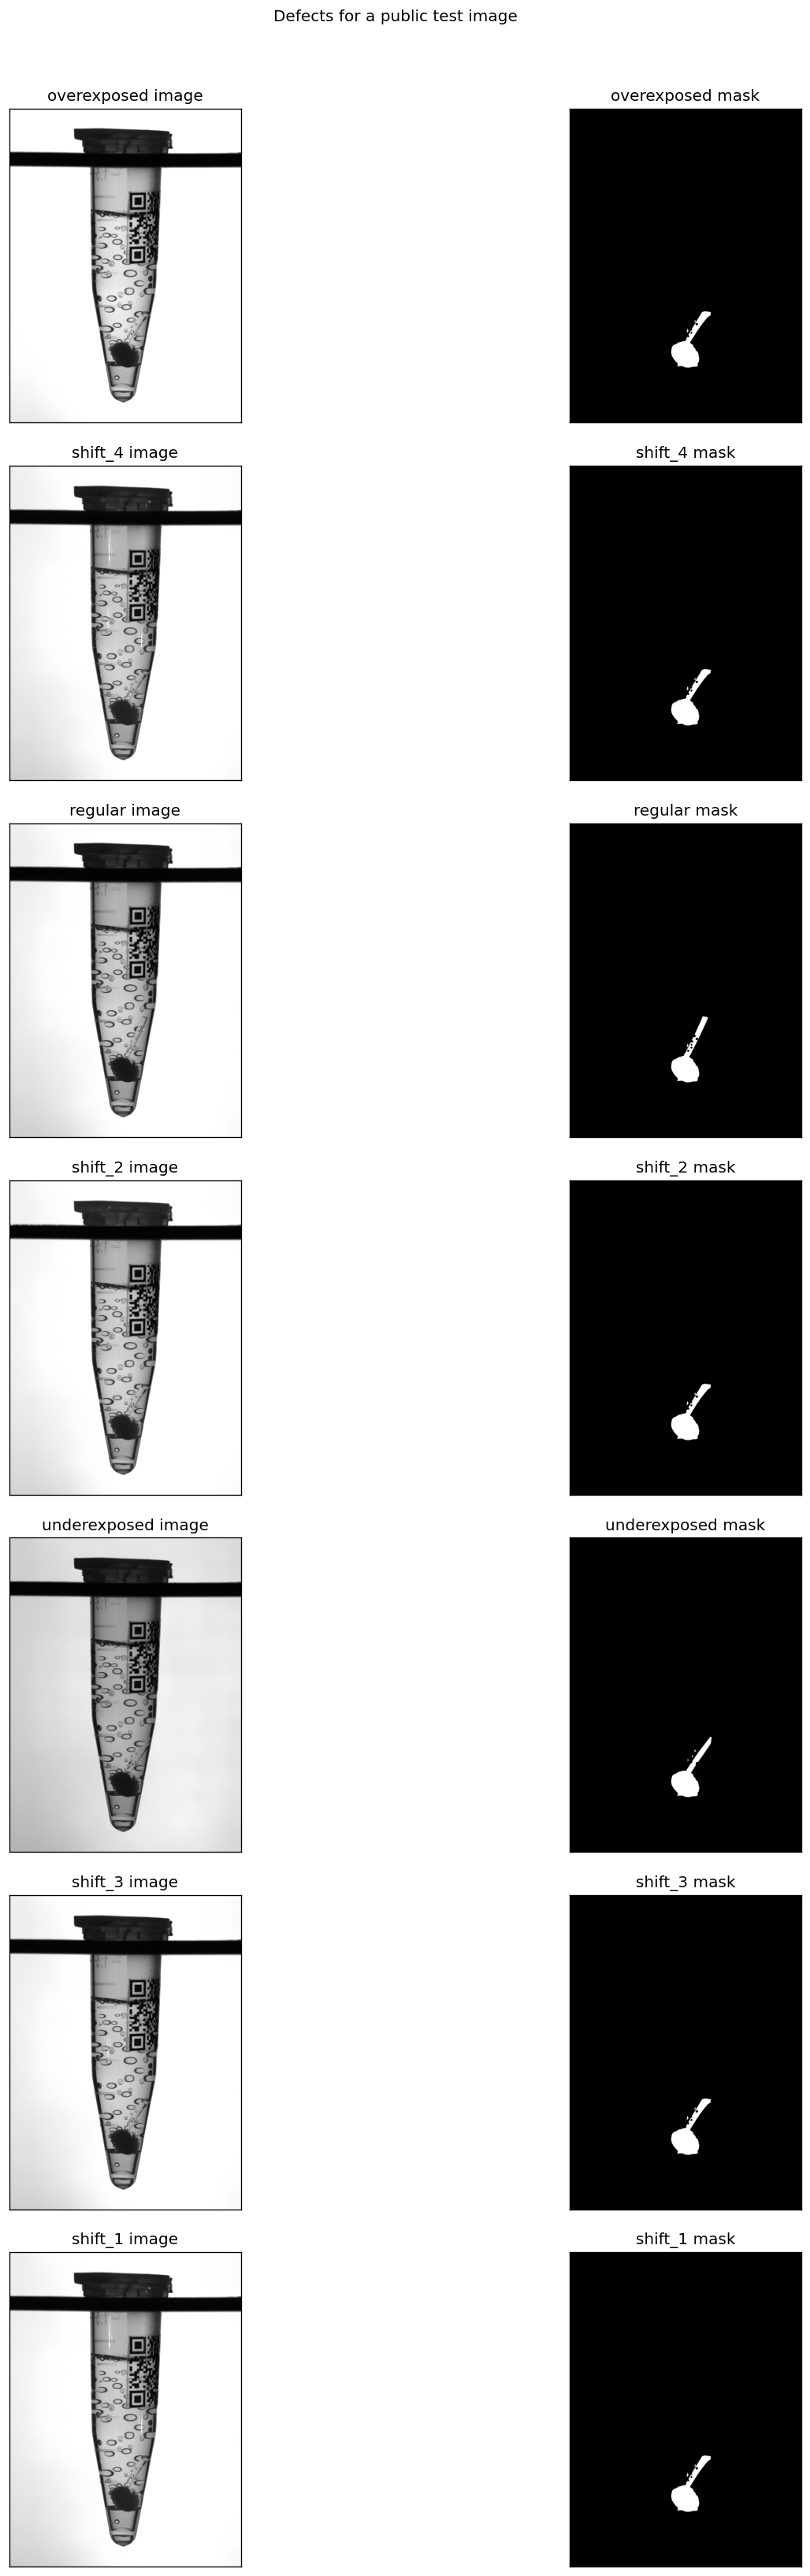

In [129]:
img_0 = public_bad_images[public_bad_images['filename'] == '000']
mask_0 = public_bad_mask[public_bad_mask['filename']=='000']

unique_defects = public_bad_images['defect'].unique()
fig,axes = plt.subplots(nrows=7, ncols=2,figsize=(12, 28), dpi=120)
plt.tight_layout(rect=[0, 0, 1, 0.95])

fig.suptitle('Defects for a public test image')


for i, defect in enumerate(public_bad_images['defect'].unique()):
    img_defect_path = img_0[img_0['defect']==defect]['path'].iloc[0]
    mask_defect_path = mask_0[mask_0['defect']==defect]['path'].iloc[0]

    img_defect = cv.imread(img_defect_path)
    img_defect = cv.cvtColor(img_defect, cv.COLOR_BGR2RGB)
    mask_defect = cv.imread(mask_defect_path)
    mask_defect = cv.cvtColor(mask_defect, cv.COLOR_BGR2RGB)

    axes[i,0].imshow(img_defect)
    axes[i,0].set_title(f'{defect} image')
    axes[i,0].get_xaxis().set_visible(False)
    axes[i,0].get_yaxis().set_visible(False)
    
    axes[i,1].imshow(mask_defect, cmap='gray')
    axes[i,1].set_title(f'{defect} mask')
    axes[i,1].get_xaxis().set_visible(False)
    axes[i,1].get_yaxis().set_visible(False)
    

Now looking at these defects, we see that the bad images have various expositions 